
Dataset Overview:
The dataset consists of the following columns:

-  person_age: Age of the person applying for the loan.
-  person_gender: Gender of the applicant.
-  person_education: Education level of the applicant.
-  person_income: Income of the applicant.
-  person_emp_exp: Years of employment experience.
-  person_home_ownership: Type of home ownership (Rent, Own, Mortgage).
-  loan_amnt: Amount of the loan applied for.
-  loan_intent: Purpose of the loan (e.g., Personal, Education, Medical).
-  loan_int_rate: Interest rate on the loan.
-  loan_percent_income: Percentage of income used for the loan.
-  cb_person_cred_hist_length: Length of the applicant's credit history.
-  credit_score: Credit score of the applicant.
-  previous_loan_defaults_on_file: Whether the applicant has previous loan defaults.
-  loan_status: Target variable (1 = Loan defaulted, 0 = Loan approved).

The goal is to predict loan_status (whether the loan will be approved or defaulted) using the features provided.


In [ ]:
# Load the Dataset

import pandas as pd
from azure.storage.blob import BlobServiceClient
from io import StringIO

# Azure blob storage connection string
connect_str = ""
container_name = "businesscases"
blob_name = ".csv"

# Create a blobserviceclient using the connection string
blob_service_client = BlobServiceClient.from_connection_string(connect_str)

# Get the container client
container_client = blob_service_client.get_container_client(container_name)

# Get the blob client for the specific file
blob_client = container_client.get_blob_client(blob_name)

# Download the blob as a string
blob_data = blob_client.download_blob()
csv_content = blob_data.readall().decode('utf-8')

# Convert the CSV string to a pandas DataFrame
df = pd.read_csv(StringIO(csv_content))

# Display the first few rows
df.head()

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 3, Finished, Available, Finished, False)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


**Task 5: Perform Exploratory Data Analysis (EDA)**

• Inspect the dataset for missing values and data types.

In [2]:
# Check for missing values
print(f"Missing values in each column:\n{df.isnull().sum()}")

# Check the data types of each column
print(f"Data types:\n{df.dtypes}")

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 4, Finished, Available, Finished, False)

Missing values in each column:
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64
Data types:
person_age                          int64
person_gender                      object
person_education                   object
person_income                       int64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                           int64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_

• Visualise the distribution of loan amounts, credit scores, and loan statuses.


StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 5, Finished, Available, Finished, False)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


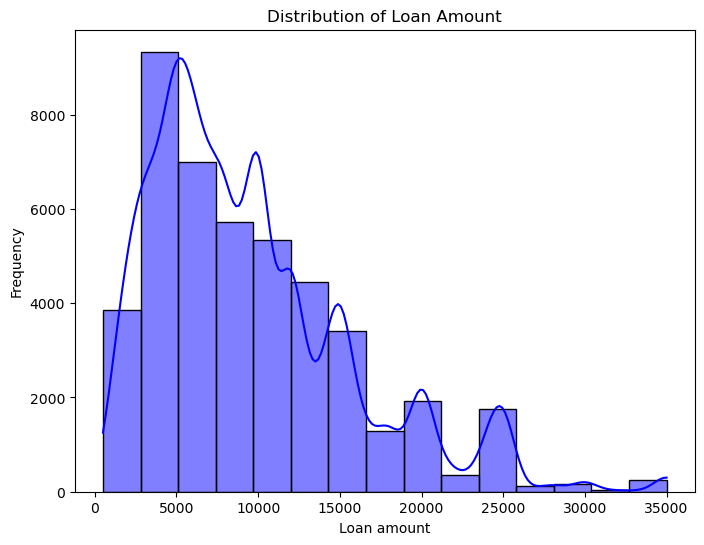

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


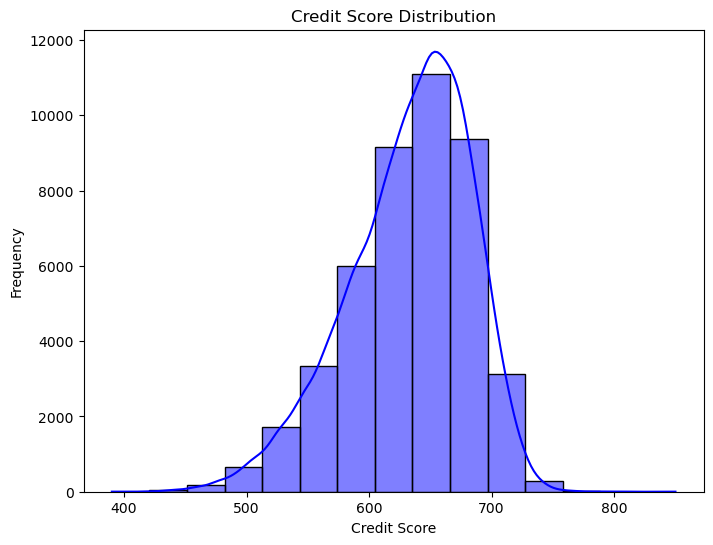

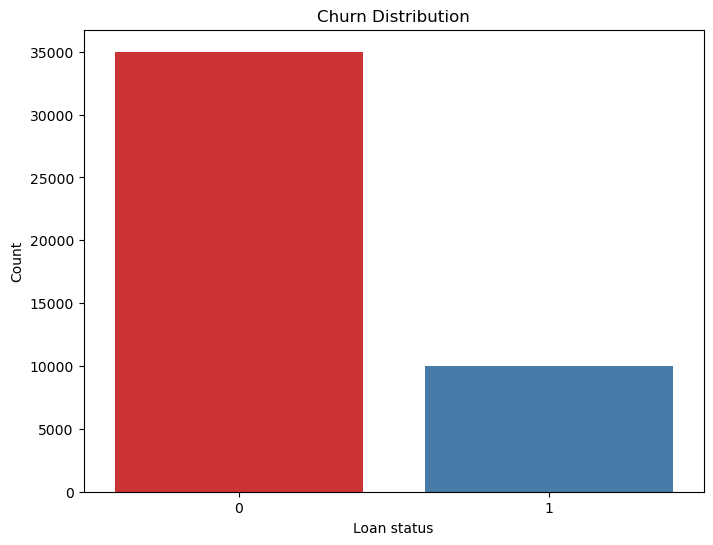

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Loan amounts distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['loan_amnt'], bins=15, kde=True, color='blue')
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan amount')
plt.ylabel('Frequency')
plt.show()

# Credit scores distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['credit_score'], bins=15, kde=True, color='blue')
plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()

# Loan status distribution (target variable)
plt.figure(figsize=(8, 6))
sns.countplot(x='loan_status', data=df, palette='Set1')
plt.title('Churn Distribution')
plt.xlabel('Loan status')
plt.ylabel('Count')
plt.show()


**Analysis of Dataset Distributions**

1. Loan Amount Distribution

    - Loan amounts are unevenly distributed.
    
    - Most loans fall in the lower to mid-range.

    - Very high loan amounts are rare.

    - The distribution is slightly right-skewed.
 
**_<u>
Interpretation:</u>_**
Most borrowers apply for moderate loans, while large loans are less common,possibly due to stricter approval policies for higher amounts.

2. Credit Score Distribution

    - Credit scores are concentrated in the mid-to-high range.

    - Very low scores are limited.

    - Extremely high scores are present but fewer.

**_<u>
Interpretation:</u>_**
The dataset represents mostly average-to-good credit borrowers. Since credit score strongly impacts repayment ability, it is likely a key predictor of loan default.

3. Loan Status Distribution (Target Variable)

    - The dataset is imbalanced.

    - Majority class: Non-default (0).

    - Minority class: Default (1).

**_<u>Interpretation:</u>_**
There are many more non-defaulters than defaulters in the dataset. Because of this imbalance, a model might mostly predict non-default cases and ignore the smaller default group. So, we cannot rely only on accuracy. Other measures like recall and precision will also be important when building the model.


• Check for correlations between features and the target variable (loan_status).
 

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 6, Finished, Available, Finished, False)

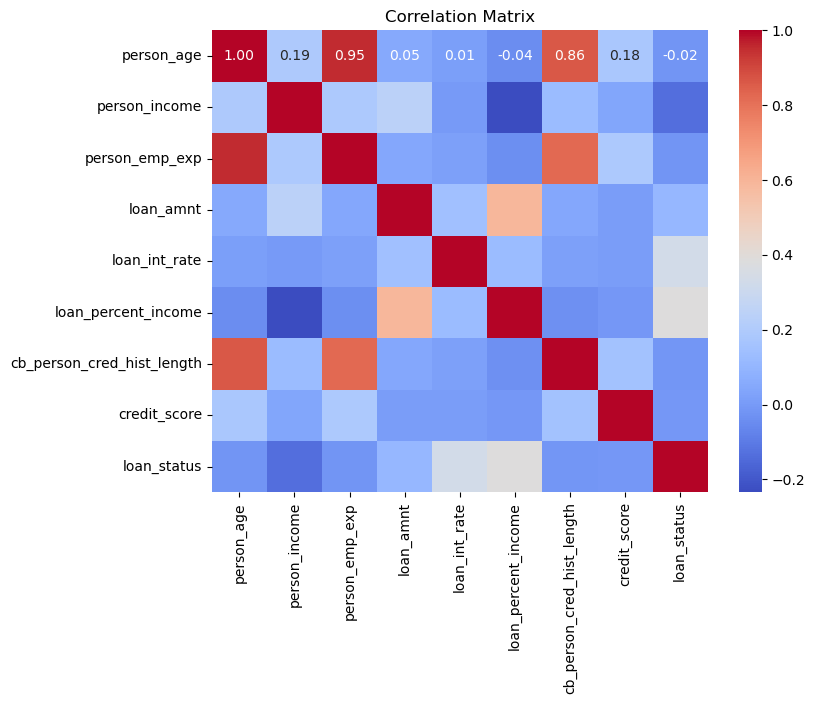

In [4]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Heatmap of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

**Correlation Matrix Analysis**

The heatmap shows the relationships between numerical variables in the dataset.

There is a strong positive correlation between:

- Age and Employment Experience

- Age and Credit History Length

- Employment Experience and Credit History Length

This indicates that older individuals tend to have more work experience and longer credit histories, which is logically expected.

Most variables show weak correlation with the target variable (loan_status). This suggests that no single feature strongly determines loan default, and prediction will likely depend on a combination of multiple factors.

Overall, the dataset contains some highly correlated demographic features, while financial features show moderate to weak relationships.

**Task 6: Data Preprocessing**

• Clean and preprocess the data:

o Handle missing values (if any).




In [5]:
df = df.fillna(df.median(numeric_only=True))
df = df.fillna("Unknown")

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 7, Finished, Available, Finished, False)

In [6]:
df.isnull().values.any()

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 8, Finished, Available, Finished, False)

False

o Encode categorical variables such as person_gender, person_education, and person_home_ownership.

In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode categorical columns
label_encoder = LabelEncoder()
df['person_gender'] = label_encoder.fit_transform(df['person_gender'])
df['person_education'] = label_encoder.fit_transform(df['person_education'])
df['person_home_ownership'] = label_encoder.fit_transform(df['person_home_ownership'])
df['loan_intent'] = label_encoder.fit_transform(df['loan_intent'])
df['previous_loan_defaults_on_file'] = label_encoder.fit_transform(df['previous_loan_defaults_on_file'])

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 9, Finished, Available, Finished, False)

In [8]:
print(df.dtypes)

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 10, Finished, Available, Finished, False)

person_age                          int64
person_gender                       int64
person_education                    int64
person_income                       int64
person_emp_exp                      int64
person_home_ownership               int64
loan_amnt                           int64
loan_intent                         int64
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length          int64
credit_score                        int64
previous_loan_defaults_on_file      int64
loan_status                         int64
dtype: object


o Split the data into features (X) and target (y).


In [9]:
# Features (X) and Target (y)

X = df[['person_age',
        'person_gender',
        'person_education',
        'person_income',
        'person_emp_exp',
        'person_home_ownership',
        'loan_amnt',
        'loan_intent',
        'loan_int_rate',
        'loan_percent_income',
        'cb_person_cred_hist_length',
        'credit_score',
        'previous_loan_defaults_on_file']]

y = df['loan_status']

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 11, Finished, Available, Finished, False)

o Split the data into training and testing sets.

In [10]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 12, Finished, Available, Finished, False)

**Task 7: Train Multiple Models**

• Train the following models to predict loan defaults:

1. Logistic Regression:

▪ This is a common model for binary classification tasks. It will predict whether a loan will default (1) or be approved (0).

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Initialize Logistic Regression model
log_reg_model = LogisticRegression()

# Train the model
log_reg_model.fit(X_train, y_train)

# Predict on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
print(f"Logistic Regression Accuracy: {log_reg_accuracy}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log_reg)

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 13, Finished, Available, Finished, False)

Logistic Regression Accuracy: 0.791


In [12]:
results_df = pd.DataFrame({
    'Actual Loan Status': y_test,
    'Predicted Loan Status (Logistic Regression)': y_pred_log_reg
})

display(results_df.head())

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 14, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 14490810-f7c8-4a21-9e56-2a10605d8853)

In [13]:
import pandas as pd

log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
print(f"Logistic Regression Accuracy: {log_reg_accuracy}")

cm = confusion_matrix(y_test, y_pred_log_reg, labels=[0, 1])
cm_df = pd.DataFrame(cm,
                     index=["Actual: 0 (Negative)", "Actual: 1 (Positive)"],
                     columns=["Predicted: 0 (Negative)", "Predicted: 1 (Positive)"])
print(cm_df)

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 15, Finished, Available, Finished, False)

Logistic Regression Accuracy: 0.791
                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     6875                      115
Actual: 1 (Positive)                     1766                      244


In [30]:
from sklearn.metrics import recall_score, precision_score

# Calculate recall for default class (1)
recall = recall_score(y_test, y_pred_log_reg)

# Calculate precision for default class (1)
precision = precision_score(y_test, y_pred_log_reg)

print("Recall:", recall)
print("Precision:", precision)

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 32, Finished, Available, Finished, False)

Recall: 0.12139303482587065
Precision: 0.6796657381615598


**Logistic Regression Model Analysis**

- The model achieved an accuracy of 79%.

- However, the recall for the default (1) class was only 12%.

- This means the model correctly identified only 12% of actual defaulters.

- The precision was 67.97%, meaning that when the model predicted a borrower as a defaulter, about 68% of those predictions were correct.

- The confusion matrix showed a high number of false negatives (e.g., 1766 defaulters predicted as non-default).

- The model performed well in predicting the majority class (non-default) but struggled with the minority class (default).

- The low recall indicates poor detection of risky borrowers.

- Since Logistic Regression assumes a linear relationship, it may not capture complex patterns in the dataset.

_<u>Conclusion:</u>_

Although Logistic Regression achieved acceptable overall **accuracy** **(79%)** and and moderate **precision (67.97%)**, its very low **recall** **(12%)** makes it unreliable for detecting defaulters. Therefore, it is not the most suitable model for this loan default prediction task.


**2. Random Forest Classifier:**

▪ This model can capture non-linear patterns and interactions between features.


In [15]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy}")

# Confusion Matrix

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[0, 1])
cm_rf = pd.DataFrame(cm_rf,
                     index=["Actual: 0 (Negative)", "Actual: 1 (Positive)"],
                     columns=["Predicted: 0 (Negative)", "Predicted: 1 (Positive)"])
print(cm_rf)

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 17, Finished, Available, Finished, False)

Random Forest Accuracy: 0.9286666666666666
                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     6797                      193
Actual: 1 (Positive)                      449                     1561


In [31]:
from sklearn.metrics import recall_score, precision_score

# Calculate Recall
recall_rf = recall_score(y_test, y_pred_rf, pos_label=1)

# Calculate Precision
precision_rf = precision_score(y_test, y_pred_rf, pos_label=1)

print("Random Forest Recall:", recall_rf)
print("Random Forest Precision:", precision_rf)

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 33, Finished, Available, Finished, False)

Random Forest Recall: 0.7766169154228856
Random Forest Precision: 0.8899657924743444


**Random Forest Model Analysis**

- The model correctly predicted 6797 non-defaulters.

- It correctly identified 1561 defaulters (True Positives).

- Only 449 defaulters were missed (False Negatives).

- The recall of 77.66% means the model successfully detects most risky borrowers.

- The precision is 88.99%, meaning that when the model predicts a borrower as a defaulter, about 89% of those predictions are correct.

- The false positive rate is low (only 193 non-defaulters wrongly classified).

_<u>Conclusion</u>_

With **92.87% accuracy**, **77.66% recall**, and **88.99% precision**, Random Forest performs very well in predicting loan defaults. It significantly outperforms Logistic Regression (12% recall) and is much more reliable for identifying high-risk customers.

**3. Gradient Boosting Model**

In [17]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators=500, learning_rate=0.1, random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_gb = gb_model.predict(X_test)

# Evaluate the model
gb_accuracy = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Accuracy: {gb_accuracy}")

# Confusion Matrix
cm_gb = confusion_matrix(y_test, y_pred_gb, labels=[0, 1])
cm_gb = pd.DataFrame(cm_gb,
                     index=["Actual: 0 (Negative)", "Actual: 1 (Positive)"],
                     columns=["Predicted: 0 (Negative)", "Predicted: 1 (Positive)"])

print(cm_gb)

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 19, Finished, Available, Finished, False)

Gradient Boosting Accuracy: 0.9316666666666666
                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     6793                      197
Actual: 1 (Positive)                      418                     1592


In [32]:
from sklearn.metrics import recall_score, precision_score

# Calculate Recall
recall_gb = recall_score(y_test, y_pred_gb, pos_label=1)

# Calculate Precision
precision_gb = precision_score(y_test, y_pred_gb, pos_label=1)

print("Gradient Boosting Recall:", recall_gb)
print("Gradient Boosting Precision:", precision_gb)

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 34, Finished, Available, Finished, False)

Gradient Boosting Recall: 0.7920398009950249
Gradient Boosting Precision: 0.8898826159865847


**Tuning Gradient Boosting Model with different parameters**

In [33]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score

for n in [100, 300, 500, 700]:
    gb = GradientBoostingClassifier(n_estimators=n, learning_rate=0.1, random_state=42)
    gb.fit(X_train, y_train)
    y_pred = gb.predict(X_test)

    print(f"\nTrees: {n}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 35, Finished, Available, Finished, False)


Trees: 100
Accuracy: 0.9201111111111111
Recall: 0.7512437810945274
Precision: 0.8733371891266628



Trees: 300
Accuracy: 0.9282222222222222
Recall: 0.7805970149253731
Precision: 0.8844419391206313



Trees: 500
Accuracy: 0.9316666666666666
Recall: 0.7920398009950249
Precision: 0.8898826159865847



Trees: 700
Accuracy: 0.932
Recall: 0.7950248756218905
Precision: 0.8887652947719689


**Short Analysis**

The results showed that both accuracy and recall increased as the number of estimators increased. The model achieved its highest performance at 700 trees, but the improvement compared to 500 trees was very small.

Therefore, 500 estimators were selected for the final model because it provides high accuracy and recall while keeping the model more efficient and avoiding unnecessary computational cost.

**Gradient Boosting Model Analysis**

The Gradient Boosting model was trained using 500 estimators (trees) with a learning rate of 0.1.
- The model correctly predicted 6793 non-defaulters.

- It correctly identified 1592 defaulters (True Positives).

- Only 418 defaulters were missed (False Negatives).

- The recall of 79.20% indicates that the model successfully detects most risky borrowers.

- The model achieved an accuracy of 93.17%, which is slightly higher than Random Forest (92.87%).

- The precision of 88.99% shows that when the model predicts a borrower will default, it is correct most of the time.

- Gradient Boosting captures complex, non-linear relationships, which improves its ability to detect loan defaults.

<u>_Conclusion_</u>

Using **500 estimators**,With **93.17%** **accuracy**,**88.99% precision** and **79.20%** **recall**, Gradient Boosting performs very strongly in predicting loan defaults. It slightly outperforms Random Forest in both accuracy and recall, making it the best performing model among the three evaluated models.


**Task 8: Evaluate the Models**

• Create table with Actual vs Predicted values for each model

In [20]:
# Create Actual vs Predicted Table for all models

comparison_df = pd.DataFrame({
    'Actual_Loan_Status': y_test,
    'Logistic_Regression_Prediction': y_pred_log_reg,
    'Random_Forest_Prediction': y_pred_rf,
    'Gradient_Boosting_Prediction': y_pred_gb
})

display(comparison_df.head())

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 22, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, de03fe9d-8fed-46e8-ada5-d4ed19ebad49)

• Compare the performance of all three models using the following metrics:

o Accuracy

o Confusion Matrix

In [21]:
accuracy_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [log_reg_accuracy, rf_accuracy, gb_accuracy]
})

display(accuracy_df)

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 23, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 7263130e-8c01-4501-8eba-c1604c950923)

In [22]:
from sklearn.metrics import confusion_matrix

# Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log_reg)

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Gradient Boosting
cm_gb = confusion_matrix(y_test, y_pred_gb)

print("Logistic Regression Confusion Matrix:\n", cm_log)
print("\nRandom Forest Confusion Matrix:\n", cm_rf)
print("\nGradient Boosting Confusion Matrix:\n", cm_gb)

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 24, Finished, Available, Finished, False)

Logistic Regression Confusion Matrix:
 [[6875  115]
 [1766  244]]

Random Forest Confusion Matrix:
 [[6797  193]
 [ 449 1561]]

Gradient Boosting Confusion Matrix:
 [[6793  197]
 [ 418 1592]]


In [34]:
from sklearn.metrics import recall_score, precision_score

def get_metrics(cm):
    TN = cm[0][0]
    FP = cm[0][1]
    FN = cm[1][0]
    TP = cm[1][1]
    return TN, FP, FN, TP

# Extract metrics
log_metrics = get_metrics(cm_log)
rf_metrics = get_metrics(cm_rf)
gb_metrics = get_metrics(cm_gb)

performance_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    
    'Accuracy': [log_reg_accuracy, rf_accuracy, gb_accuracy],
    
    'Recall': [
        recall_score(y_test, y_pred_log_reg),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    
    'Precision': [
        precision_score(y_test, y_pred_log_reg),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    
    'True Negatives': [log_metrics[0], rf_metrics[0], gb_metrics[0]],
    'False Positives': [log_metrics[1], rf_metrics[1], gb_metrics[1]],
    'False Negatives': [log_metrics[2], rf_metrics[2], gb_metrics[2]],
    'True Positives': [log_metrics[3], rf_metrics[3], gb_metrics[3]]
})

print("Complete Model Performance Comparison:")
display(performance_df)

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 36, Finished, Available, Finished, False)

Complete Model Performance Comparison:


SynapseWidget(Synapse.DataFrame, 506bdd2b-3374-41db-b929-32f9e2d6f4ee)

**Task 10: Creating a Table in the Microsoft Fabric DataLakehouse**

In [24]:
df_results = comparison_df

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 26, Finished, Available, Finished, False)

In [25]:
df_results_spark = spark.createDataFrame(df_results)

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 27, Finished, Available, Finished, False)

In [26]:
df_results_spark.createOrReplaceTempView("df_results_spark_view")

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 28, Finished, Available, Finished, False)

In [27]:
df_spark = spark.table("df_results_spark_view")

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 29, Finished, Available, Finished, False)

In [28]:
df_spark.write.mode("overwrite") \
.option("overwriteSchema", "true") \
.format("delta") \
.saveAsTable("Team2_Mission5_Table")

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 30, Finished, Available, Finished, False)

In [29]:
spark.sql("SELECT * FROM Team2_Mission5_Table").show()

StatementMeta(, 02b11448-4d33-4180-bd6c-c639c1a8cfd3, 31, Finished, Available, Finished, False)

+------------------+------------------------------+------------------------+----------------------------+
|Actual_Loan_Status|Logistic_Regression_Prediction|Random_Forest_Prediction|Gradient_Boosting_Prediction|
+------------------+------------------------------+------------------------+----------------------------+
|                 0|                             0|                       0|                           0|
|                 0|                             0|                       0|                           0|
|                 1|                             0|                       1|                           1|
|                 0|                             0|                       0|                           0|
|                 1|                             0|                       1|                           1|
|                 0|                             0|                       0|                           0|
|                 0|                          

##### **Task 11: Conclusion**

**Final Insights**

_<u>**Logistic Regression:**</u>_
Logistic Regression is a simple and interpretable model suitable for binary classification problems. However, it assumes a linear relationship between variables and the target. In this project, Logistic Regression achieved reasonable accuracy but had **very low recall (12%)**, meaning it struggled to correctly identify many defaulters. Although its **precision was relatively high (~68%)**, the model failed to detect most risky borrowers, making it less suitable for this loan default prediction task.

_<u>**Random Forest:**</u>_
Random Forest is a powerful ensemble model that combines multiple decision trees. It can capture complex and non-linear relationships in the data. In this project, Random Forest performed significantly better than Logistic Regression, achieving **high accuracy (92.87%)**, **strong recall (77.66%)**, and **high precision (~88.99%)**., making it more effective at identifying risky borrowers.


_<u>**Gradient Boosting:**</u>_
Gradient Boosting further improved the results by building trees sequentially to correct the errors of previous trees. After tuning the number of estimators, the model achieved the **highest accuracy (93.17%) ,highest recall (79.20%)**,)and **very high precision (~88.99%)**, making it the best performing model for loan default prediction in this project.

<u>**Overall Conclusion:**</u>
Among the three models evaluated, **Gradient Boosting performed the best**, as it provided the best balance between accuracy, recall, and precision, making it the most reliable model for identifying potential loan defaulters.



##### **Explanation of Model Tuning in Gradient Boosting**

Gradient Boosting is a strong machine learning model that builds multiple decision trees step by step. Each new tree learns from the mistakes of the previous tree. To make the model perform better, we adjust some settings called hyperparameters. This process is called model tuning.


**Number of Estimators (n_estimators)**

- What it is:
This parameter decides how many decision trees the model will build.

- Why it matters:
More trees usually help the model learn better patterns from the data. However, adding too many trees can increase training time and may not improve performance much.

- What we did:
We tested different values such as 100, 300, 500, and 700 trees.

- What we observed:
Accuracy and recall improved as the number of trees increased. Although 700 trees gave slightly better results, the improvement compared to 500 trees was very small.

<u>**Final decision:**</u>
We selected 500 estimators because it provides high accuracy and recall while keeping the model efficient.

**Learning Rate (learning_rate)**

- What it is:
The learning rate controls how quickly the model learns from its mistakes.

- Why it matters:
If the learning rate is too high, the model may learn too quickly and make unstable predictions. If it is too low, the model will learn very slowly.

- What we did:
We used a learning rate of 0.1, which allows the model to learn at a balanced speed while still achieving good performance.

**Key Insight**

By tuning parameters like number of estimators and learning rate, the Gradient Boosting model can perform better. In this project, 500 estimators with a learning rate of 0.1 gave a good balance between accuracy, recall, and efficiency, making it the best configuration for the final model.
